## **Gene Expression Cancer RNA-Seq**

**Group Members:** Carlos John DeJesus, Maria Virla Eliza G. Getalado, Mark Joseph P. Santos (BSM CS 4B)

This dataset contains RNA sequencing (RNA-Seq) gene expression values for different cancer types. Each sample represents a patient, and each feature corresponds to the expression level of a specific gene. The goal of this activity is to classify cancer types based on gene expression patterns using machine learning.

A dirty version of the dataset (with missing values, duplicate rows, inconsistent column names, and irregular sample identifiers) was used. The dataset was then cleaned and preprocessed before applying classification models such as Logistic Regression and Random Forest.

This activity demonstrates a complete machine learning workflow, including data inspection, data cleaning, feature selection, model training, evaluation, and interpretation of results.

## **Cancer Types**

The dataset includes five different cancer types, represented by the following acronyms:

| Label | Cancer Type |
|--------|-------------|
| BRCA   | Breast Invasive Carcinoma |
| COAD   | Colon Adenocarcinoma |
| KIRC   | Kidney Renal Clear Cell Carcinoma |
| LUAD   | Lung Adenocarcinoma |
| PRAD   | Prostate Adenocarcinoma |

## **STEP 1: Import Necessary Libraries**

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)
sns.set_style("whitegrid")

## **STEP 2: Load the CSV Files**

**1. data_dirty.csv**
This file contains the gene expression data obtained from RNA-Seq experiments. Each row represents a sample (patient), and each column corresponds to a gene feature, showing its expression level. This dataset includes missing values, duplicate rows, inconsistent column names, irregular sample identifiers, and outliers. This is used to demonstrate data cleaning and preprocessing techniques.

**2. labels.csv**
This file contains the corresponding class labels for each sample. It maps each sample ID to a specific cancer type (BRCA, COAD, KIRC, LUAD, PRAD). This dataset is used as the target variable for classification models.

In [3]:
# Load the files

data_df = pd.read_csv(r"C:\Users\new user\Downloads\archive1\data_dirty.csv")
labels_df = pd.read_csv(r"C:\Users\new user\Downloads\archive1\labels.csv")

print("Dirty data shape:", data_df.shape)
print("Labels shape:", labels_df.shape)

Dirty data shape: (811, 20532)
Labels shape: (801, 2)


## **STEP 3: Inspect the dataset**

In [6]:
# Inspect the dataset

print("=== DATA HEAD ===")
display(data_df.head())

print("=== LABELS HEAD ===")
display(labels_df.head())

print("=== DATA INFO ===")
data_df.info()

print("\n=== LABELS INFO ===")
labels_df.info()

print("\n=== DATA DESCRIBE ===")
display(data_df.describe())

print("\n=== LABELS DESCRIBE ===")
display(labels_df.describe(include=["object", "string"]))

=== DATA HEAD ===


,UNNAMED: 0,gene_0,GENE_1,GENE_2,gene_3,gene_4,gene_5,GENE_6,GENE_7,gene_8,GENE_9,GENE_10,GENE_11,GENE_12,GENE_13,GENE_14,GENE_15,GENE_16,GENE_17,GENE_18,gene_19,GENE_20,GENE_21,gene_22,gene_23,...,gene_20506,GENE_20507,GENE_20508,GENE_20509,GENE_20510,gene_20511,gene_20512,gene_20513,gene_20514,gene_20515,GENE_20516,GENE_20517,GENE_20518,GENE_20519,gene_20520,GENE_20521,GENE_20522,gene_20523,gene_20524,gene_20525,gene_20526,GENE_20527,gene_20528,gene_20529,GENE_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,0.591871,1.334282,2.015391,0.591871,0.0,0.0,0.0,0.0,0.591871,5.619994,1.334282,0.000000,9.796088,0.0,...,7.846957,2.824951,6.239396,0.000000,8.469593,0.0,6.535978,6.968701,7.128881,7.175175,9.249369,7.025970,8.045563,7.475709,7.205236,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,SAMPLE_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,0.000000,0.587845,2.466601,1.004394,0.0,0.0,0.0,0.0,0.000000,11.055208,3.562621,0.000000,10.070470,0.0,...,7.161001,0.000000,4.708877,0.811142,8.451689,0.0,7.242336,8.046284,6.047558,8.572901,7.549030,7.019935,9.458940,9.190867,10.639259,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,0.000000,0.452595,1.981122,1.074163,0.0,0.0,0.0,0.0,1.683023,8.210248,4.195285,3.660427,8.970920,0.0,...,7.527555,0.000000,4.997902,0.796598,7.761132,0.0,6.820460,8.048983,6.661493,7.716332,6.745802,7.524667,8.602350,9.036654,10.336027,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,0.000000,0.434882,2.874246,0.000000,0.0,0.0,0.0,0.0,1.267356,8.306317,3.573556,0.000000,8.524616,0.0,...,8.319085,1.791814,5.661134,1.464093,8.625727,0.0,7.420095,7.784746,7.613915,8.963286,7.744699,7.924997,8.981473,8.665592,9.194823,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,sample_SAMPLE_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,0.000000,1.275841,2.141204,0.000000,0.0,0.0,0.0,0.0,0.889707,10.149150,2.967630,0.000000,8.047238,0.0,...,8.227717,0.360982,6.227104,0.649386,8.151879,0.0,6.558289,8.673708,6.505099,8.948989,7.010366,7.364056,8.950646,8.233366,9.298775,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


=== LABELS HEAD ===


,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


=== DATA INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 811 entries, 0 to 810
Columns: 20532 entries, UNNAMED: 0  to GENE_20530
dtypes: float64(20531), str(1)
memory usage: 127.0 MB

=== LABELS INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  801 non-null    str  
 1   Class       801 non-null    str  
dtypes: str(2)
memory usage: 12.6 KB

=== DATA DESCRIBE ===


,gene_0,GENE_1,GENE_2,gene_3,gene_4,gene_5,GENE_6,GENE_7,gene_8,GENE_9,GENE_10,GENE_11,GENE_12,GENE_13,GENE_14,GENE_15,GENE_16,GENE_17,GENE_18,gene_19,GENE_20,GENE_21,gene_22,gene_23,gene_24,...,gene_20506,GENE_20507,GENE_20508,GENE_20509,GENE_20510,gene_20511,gene_20512,gene_20513,gene_20514,gene_20515,GENE_20516,GENE_20517,GENE_20518,GENE_20519,gene_20520,GENE_20521,GENE_20522,gene_20523,gene_20524,gene_20525,gene_20526,GENE_20527,gene_20528,gene_20529,GENE_20530
count,811.000000,811.000000,811.000000,811.000000,811.000000,811.0,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.0,811.000000,...,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000
mean,0.026995,3.021196,3.104379,6.724181,9.811715,0.0,7.398118,0.498202,0.016538,0.013263,0.684728,0.956568,2.663920,0.316996,0.214433,0.005806,0.002965,0.037138,2.202164,9.086466,3.287364,2.569896,8.262030,0.0,0.104203,...,8.042926,1.046607,6.030647,1.218873,8.144162,0.043715,6.855452,8.516078,7.347556,8.565381,8.021442,7.314592,8.688239,8.325630,8.787117,5.897545,8.765579,10.057384,4.849191,9.746610,11.744797,10.157902,9.592610,5.520547,0.094982
std,0.137283,1.200817,1.064561,0.638567,0.506061,0.0,1.108702,0.507301,0.132821,0.203460,1.169242,0.874386,0.710223,0.671701,0.395014,0.064915,0.038256,0.195568,3.189811,1.203484,1.133225,2.447153,1.218181,0.0,0.409172,...,0.601524,1.260091,0.644262,0.701877,0.513028,0.174382,0.606229,0.740030,1.510156,0.636762,0.642599,0.577333,0.542967,0.823492,1.264564,0.745437,0.600479,0.379413,2.384324,0.535479,0.669183,0.580072,0.563358,2.076537,0.362855
min,0.000000,0.000000,0.000000,5.009284,8.435999,0.0,3.930747,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.437228,0.000000,0.000000,4.190164,0.0,0.000000,...,4.322945,0.000000,3.488194,0.000000,6.355971,0.000000,4.686904,5.555325,0.000000,5.709908,4.567479,0.000000,6.655299,6.294446,4.077841,2.853517,6.678368,8.669456,0.000000,7.974942,9.045255,7.530141,7.864533,0.593975,0.000000
25%,0.000000,2.304086,2.393718,6.303704,9.461381,0.0,6.652792,0.000000,0.000000,0.000000,0.000000,0.397967,2.234730,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.295976,2.591140,0.000000,7.589519,0.0,0.000000,...,7.683675,0.000000,5.660081,0.743644,7.824478,0.000000,6.472955,8.028983,6.708455,8.201119,7.624360,6.988320,8.365859,7.713589,7.832886,5.455498,8.384488,9.826049,3.128919,9.404892,11.320893,9.836592,9.245395,4.089640,0.000000
50%,0.000000,3.151339,3.133547,6.659068,9.790961,0.0,7.442098,0.442227,0.000000,0.000000,0.356482,0.807520,2.699529,0.000000,0.000000,0.000000,0.000000,0.000000,0.642101,9.164643,3.321943,2.511215,8.257430,0.0,0.000000,...,8.087463,0.704783,6.079199,1.208892,8.171867,0.000000,6.820102,8.476540,7.681962,8.588542,8.039380,7.328513,8.667271,8.335216,8.826501,5.970509,8.789583,10.066385,5.435152,9.784869,11.757511,10.194166,9.568401,5.209192,0.000000
75%,0.000000,3.887139,3.805777,7.041867,10.142145,0.0,8.118070,0.786763,0.000000,0.000000,0.901144,1.371278,3.151842,0.424597,0.400920,0.000000,0.000000,0.000000,2.720982,9.942779,4.041733,4.913397,9.011590,0.0,0.000000,...,8.441447,1.551144,6.399425,1.647383,8.450844,0.000000,7.164573,8.946839,8.387470,8.965701,8.430737,7.642366,9.016145,8.860927,9.774404,6.403529,9.142569,10.302804,6.644111,10.086267,12.178951,10.578741,9.918327,6.873016,0.000000
max,1.482332,6.237034,6.063484,10.129528,11.355621,0.0,10.718190,2.779008,1.785592,4.067604,12.293023,7.884439,4.783661,5.547931,2.991826,1.000000,0.581881,2.565427,10.861645,12.462622,7.164595,7.781347,13.135341,0.0,3.602540,...,10.472356,8.911497,9.252710,5.785935,10.001169,1.


=== LABELS DESCRIBE ===


,Unnamed: 0,Class
count,801,801
unique,801,5
top,sample_0,BRCA
freq,1,300


## **STEP 4: Identify problems and inconsistencies in the dataset**

In [7]:
# Identify problems in the dataset

print("=== MISSING VALUES IN DATA ===")
print(data_df.isnull().sum().sum())

print("\n=== MISSING VALUES PER COLUMN (TOP 20) ===")
display(data_df.isnull().sum().sort_values(ascending=False).head(20))

print("\n=== DUPLICATE ROWS IN DATA ===")
print(data_df.duplicated().sum())

print("\n=== ORIGINAL DATA COLUMN NAMES (FIRST 20) ===")
print(data_df.columns[:20].tolist())

print("\n=== SAMPLE ID COLUMN VALUES (FIRST 20) ===")
print(data_df.iloc[:20, 0].tolist())

=== MISSING VALUES IN DATA ===
301

=== MISSING VALUES PER COLUMN (TOP 20) ===


gene_7400      2
gene_2967      2
gene_17749     2
GENE_8529      1
GENE_3436      1
GENE_7574      1
GENE_1931      1
gene_8096      1
GENE_7543      1
GENE_161       1
gene_1306      1
gene_5878      1
GENE_8666      1
GENE_5699      1
GENE_9662      1
gene_1816      1
GENE_5881      1
gene_8322      1
GENE_8716      1
gene_4465      1
dtype: int64


=== DUPLICATE ROWS IN DATA ===
3

=== ORIGINAL DATA COLUMN NAMES (FIRST 20) ===
['UNNAMED: 0 ', 'gene_0', 'GENE_1 ', 'GENE_2', 'gene_3', 'gene_4', 'gene_5', 'GENE_6', 'GENE_7 ', 'gene_8 ', 'GENE_9', 'GENE_10', 'GENE_11', 'GENE_12', 'GENE_13 ', 'GENE_14', 'GENE_15 ', 'GENE_16 ', 'GENE_17', 'GENE_18 ']

=== SAMPLE ID COLUMN VALUES (FIRST 20) ===
['sample_0', 'SAMPLE_1 ', 'sample_2', 'sample_3', 'sample_SAMPLE_4', 'sample_sample_5', 'sample_sample_6', 'SAMPLE_7 ', 'sample_8', 'sample_9', 'sample_10', 'sample_11', 'sample_12', 'SAMPLE_13 ', 'sample_sample_14', 'sample_15', 'sample_SAMPLE_16', 'SAMPLE_17 ', 'sample_18', 'sample_19']


## **STEP 5: Data Cleaning**

In [8]:
# Clean the dataset

clean_data = data_df.copy()
clean_labels = labels_df.copy()

# Clean column names
clean_data.columns = (
    clean_data.columns
    .str.strip()
    .str.lower()
    .str.replace("__", "_", regex=False)
)

clean_labels.columns = (
    clean_labels.columns
    .str.strip()
    .str.lower()
)

# Rename ID columns
clean_data = clean_data.rename(columns={clean_data.columns[0]: "sample_id"})
clean_labels = clean_labels.rename(columns={clean_labels.columns[0]: "sample_id", clean_labels.columns[1]: "class"})

# Clean sample_id values
clean_data["sample_id"] = clean_data["sample_id"].astype(str).str.strip().str.lower()
clean_labels["sample_id"] = clean_labels["sample_id"].astype(str).str.strip().str.lower()

# Remove exact duplicate rows
clean_data = clean_data.drop_duplicates()

# Remove duplicate sample IDs, keep first
clean_data = clean_data.drop_duplicates(subset="sample_id", keep="first")
clean_labels = clean_labels.drop_duplicates(subset="sample_id", keep="first")

# Check shapes after cleaning duplicates
print("Clean data shape after duplicates removed:", clean_data.shape)
print("Clean labels shape after duplicates removed:", clean_labels.shape)

Clean data shape after duplicates removed: (804, 20532)
Clean labels shape after duplicates removed: (801, 2)


## **STEP 6: Handle missing values**

In [41]:
# Handle missing values

missing_before = clean_data.isnull().sum().sum()
print("Missing values before cleaning:", missing_before)

# Separate sample_id first
sample_ids = clean_data["sample_id"]
features_only = clean_data.drop(columns=["sample_id"])

# Fill numeric missing values with median
features_only = features_only.apply(pd.to_numeric, errors="coerce")
features_only = features_only.fillna(features_only.median())

clean_data = pd.concat([sample_ids, features_only], axis=1)

missing_after = clean_data.isnull().sum().sum()
print("Missing values after cleaning:", missing_after)

Missing values before cleaning: 0
Missing values after cleaning: 0


## **STEP 7: Merge Cleaned Data with Labels**

In [10]:
# Merge data with labels

merged_df = pd.merge(clean_data, clean_labels, on="sample_id", how="inner")

print("Merged dataset shape:", merged_df.shape)
display(merged_df.head())

print("Class distribution:")
print(merged_df["class"].value_counts())

Merged dataset shape: (568, 20533)


,sample_id,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,gene_10,gene_11,gene_12,gene_13,gene_14,gene_15,gene_16,gene_17,gene_18,gene_19,gene_20,gene_21,gene_22,gene_23,...,gene_20507,gene_20508,gene_20509,gene_20510,gene_20511,gene_20512,gene_20513,gene_20514,gene_20515,gene_20516,gene_20517,gene_20518,gene_20519,gene_20520,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,class
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,0.591871,1.334282,2.015391,0.591871,0.000000,0.0,0.0,0.0,0.591871,5.619994,1.334282,0.000000,9.796088,0.0,...,2.824951,6.239396,0.000000,8.469593,0.0,6.535978,6.968701,7.128881,7.175175,9.249369,7.025970,8.045563,7.475709,7.205236,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,0.000000,0.587845,2.466601,1.004394,0.000000,0.0,0.0,0.0,0.000000,11.055208,3.562621,0.000000,10.070470,0.0,...,0.000000,4.708877,0.811142,8.451689,0.0,7.242336,8.046284,6.047558,8.572901,7.549030,7.019935,9.458940,9.190867,10.639259,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,0.000000,0.452595,1.981122,1.074163,0.000000,0.0,0.0,0.0,1.683023,8.210248,4.195285,3.660427,8.970920,0.0,...,0.000000,4.997902,0.796598,7.761132,0.0,6.820460,8.048983,6.661493,7.716332,6.745802,7.524667,8.602350,9.036654,10.336027,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,0.000000,0.434882,2.874246,0.000000,0.000000,0.0,0.0,0.0,1.267356,8.306317,3.573556,0.000000,8.524616,0.0,...,1.791814,5.661134,1.464093,8.625727,0.0,7.420095,7.784746,7.613915,8.963286,7.744699,7.924997,8.981473,8.665592,9.194823,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
4,sample_7,0.0,2.854853,1.750478,7.226720,9.758691,0.0,5.952103,0.000000,0.0,0.0,0.441802,0.000000,2.405856,0.000000,0.779554,0.0,0.0,0.0,0.000000,7.373431,2.304861,0.000000,8.922008,0.0,...,0.000000,5.516860,1.282855,7.849668,0.0,6.472199,7.653110,7.603471,8.468738,8.466199,7.110896,8.358093,7.422199,6.460507,5.297833,8.277092,9.599230,5.244290,9.994339,12.670377,9.987733,9.216872,6.551490,0.0,PRAD


Class distribution:
class
BRCA    211
LUAD    104
KIRC     98
PRAD     97
COAD     58
Name: count, dtype: int64


## **STEP 8: Visualize Class Distribution**

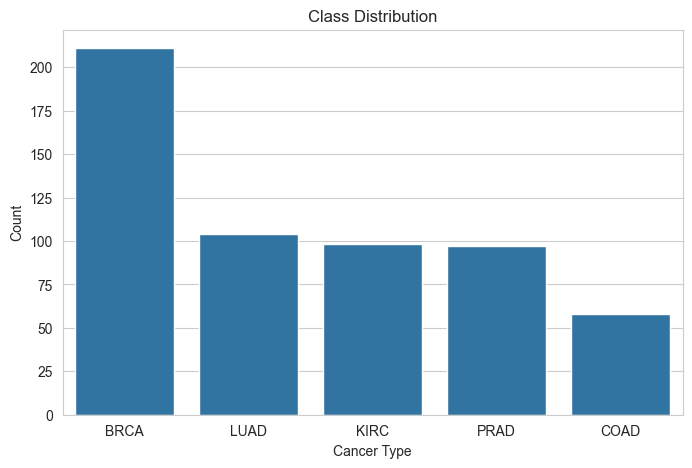

In [11]:
# Visualize class distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=merged_df, x="class", order=merged_df["class"].value_counts().index)
plt.title("Class Distribution")
plt.xlabel("Cancer Type")
plt.ylabel("Count")
plt.show()

## **STEP 9: Prepare features and target**

In [12]:
# Prepare features and target

X = merged_df.drop(columns=["sample_id", "class"])
y = merged_df["class"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Feature matrix shape:", X.shape)
print("Target shape:", y_encoded.shape)
print("Classes:", label_encoder.classes_)

Feature matrix shape: (568, 20531)
Target shape: (568,)
Classes: ['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']


## **STEP 10: Train-test Split**

In [13]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (454, 20531)
X_test: (114, 20531)
y_train: (454,)
y_test: (114,)


## **STEP 11: Logistic Regression**

In [30]:
# Logistic Regression Pipeline

k_features = 50  # you may change this to 100, 200, 300, etc.

logreg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=k_features)),
    ("model", LogisticRegression(max_iter=5000))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_logreg, target_names=label_encoder.classes_))

Logistic Regression Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        42
        COAD       1.00      1.00      1.00        12
        KIRC       1.00      1.00      1.00        20
        LUAD       1.00      1.00      1.00        21
        PRAD       1.00      1.00      1.00        19

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



## **STEP 12: Logistic Regression Confusion Matrix**

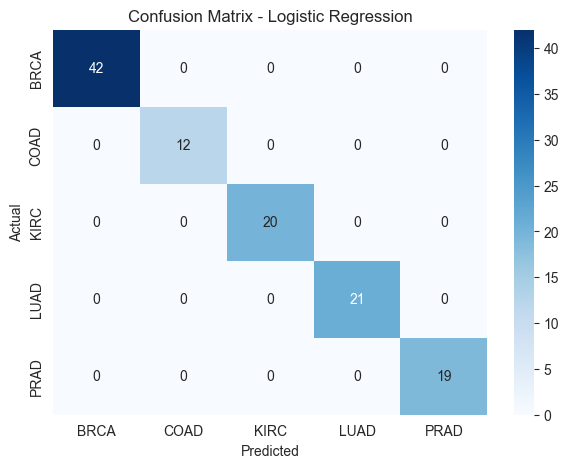

In [31]:
# Logistic Regression Confusion Matrix

cm_logreg = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **STEP 13: Random Forest**

In [32]:
# Random Forest Pipeline

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold(threshold=0.0)),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=k_features)),
    ("model", RandomForestClassifier(
        n_estimators=50,
        max_depth=8,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Random Forest Accuracy: 0.9912280701754386

Classification Report:

              precision    recall  f1-score   support

        BRCA       1.00      0.98      0.99        42
        COAD       1.00      1.00      1.00        12
        KIRC       1.00      1.00      1.00        20
        LUAD       0.95      1.00      0.98        21
        PRAD       1.00      1.00      1.00        19

    accuracy                           0.99       114
   macro avg       0.99      1.00      0.99       114
weighted avg       0.99      0.99      0.99       114



## **STEP 14: Random Forest Confusion Matrix**

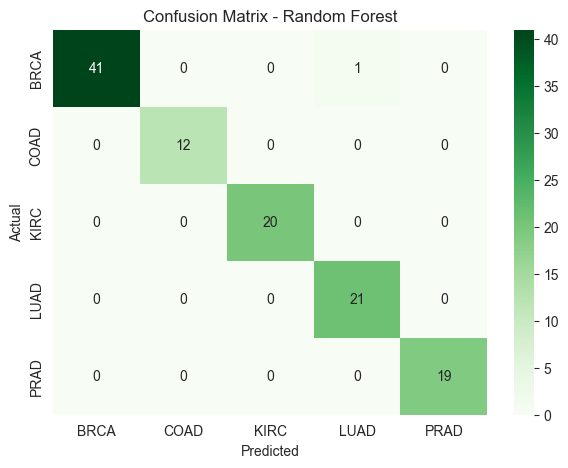

In [33]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **STEP 15: Model Comparison**

,Model,Accuracy
0,Logistic Regression,1.000000
1,Random Forest,0.991228


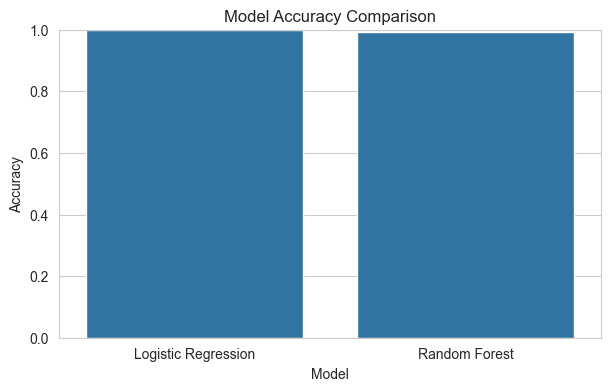

In [34]:
# Compare models

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_rf)
    ]
})

display(results)

plt.figure(figsize=(7, 4))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.show()

## **STEP 16: Cross-Validation for more Reliable Evaluation**

In [ ]:
# Cross-validation for Logistic Regression

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

logreg_cv_scores = cross_val_score(logreg_pipeline, X, y_encoded, cv=cv, scoring="accuracy")

print("Logistic Regression CV Scores:", logreg_cv_scores)
print("Logistic Regression Mean CV Accuracy:", logreg_cv_scores.mean())

Logistic Regression CV Scores: [0.99473684 1.         1.        ]
Logistic Regression Mean CV Accuracy: 0.9982456140350878


In [36]:
# Cross-validation for Random Forest

rf_cv_scores = cross_val_score(rf_pipeline, X, y_encoded, cv=cv, scoring="accuracy")

print("\nRandom Forest CV Scores:", rf_cv_scores)
print("Random Forest Mean CV Accuracy:", rf_cv_scores.mean())


Random Forest CV Scores: [0.98947368 1.         0.99470899]
Random Forest Mean CV Accuracy: 0.9947275596398404


## **Results and Discussion**

- The dataset was successfully cleaned, reducing missing values from **301 to 0** and removing all duplicate rows (**3 to 0**). The final dataset used for modeling contained **568 samples** and **20,531 gene features**, making it a high-dimensional dataset.

- The class distribution shows that **BRCA (211 samples)** is the most represented class, while **COAD (58 samples)** is the least. Despite this imbalance, all five cancer types were sufficiently represented for classification.

- Logistic Regression achieved a perfect accuracy of **1.0000**, while Random Forest achieved an accuracy of **0.9912**. These results indicate that gene expression features are highly effective in distinguishing between the cancer types **(BRCA, COAD, KIRC, LUAD, PRAD)**.

- Cross-validation results further confirm strong model performance. Logistic Regression obtained a mean accuracy of **0.9982**, while Random Forest achieved **0.9947**, showing consistent performance across different data splits.

- However, the extremely high accuracy values suggest that the dataset may be highly separable or that the models may be slightly overfitting due to the large number of features compared to the number of samples. Despite this, cross-validation results indicate that the models still generalize well.

- Overall, the results demonstrate that gene expression data can be effectively used to classify cancer types, with both models successfully capturing the underlying biological patterns.